# Implementing Proximal Policy Optimization (2 pts)

**Note:** this is alternative hometask 5, which is probably a bit harder than TD3 / SAC.

In this notebook you will be implementing Proximal Policy Optimization algorithm, 
scaled up version of which was used to train [OpenAI Five](https://openai.com/blog/openai-five/) 
to [win](https://openai.com/blog/how-to-train-your-openai-five/) against the
world champions in Dota 2.
You will be solving a continuous control environment on which it may be easier and faster 
to train an agent, however note that PPO here may not be the best algorithm as, for example,
Deep Deterministic Policy Gradient and Soft Actor Critic may be more suited 
for continuous control environments. 

For now, let's start with our environment. There are different physics simulations out there (e.g. MuJoKo), we will use PyBullet. To run the environment you will need to install 
[pybullet-gym](https://github.com/benelot/pybullet-gym):

In [1]:
!git clone https://github.com/benelot/pybullet-gym lib/pybullet-gym
!pip install -e lib/pybullet-gym
!pip install gym==0.25.2
!pip install numpy==1.23.5

fatal: destination path 'lib/pybullet-gym' already exists and is not an empty directory.


Obtaining file:///root/workspace/lib/pybullet-gym
  Preparing metadata (setup.py) ... done
  Attempting uninstall: pybulletgym
    Found existing installation: pybulletgym 0.1
    Uninstalling pybulletgym-0.1:
      Successfully uninstalled pybulletgym-0.1
  DEPRECATION: Legacy editable install of pybulletgym==0.1 from file:///root/workspace/lib/pybullet-gym (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop for pybulletgym

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26

In [1]:
import gym 
import pybulletgym

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


The overall structure of the code is similar to the one in the A2C optional homework, but don't worry if you haven't done it, it should be relatively easy to figure it out. 

First, we will create an instance of the environment. The first wrapper will simply write summaries, mainly, the total reward during an episode. Then we will *normalize* the observations and rewards: subtract running mean from observations and rewards and divide the resulting quantities by the running variances.

WalkerBase::__init__
argv[0]=
argv[0]=
observation space:  Box(-inf, inf, (17,), float32) 
observations: [ 0.99175037 -0.4745369   0.99649913 -0.99594565 -0.93245179 -0.98684726
  0.88381776 -0.03052255  0.          0.          0.          0.
  0.          0.          0.          0.          0.        ]
action space:  Box(-1.0, 1.0, (6,), float32) 
action_sample:  [-0.11848385 -0.09932256  0.6053839   0.43514547 -0.28835112  0.4699203 ]
observation shape (17,)


pybullet build time: Jan 29 2025 23:17:20
/root/workspace/lib/pybullet-gym/pybulletgym/envs/mujoco/envs/env_bases.py:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/usr/local/lib/python3.11/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=

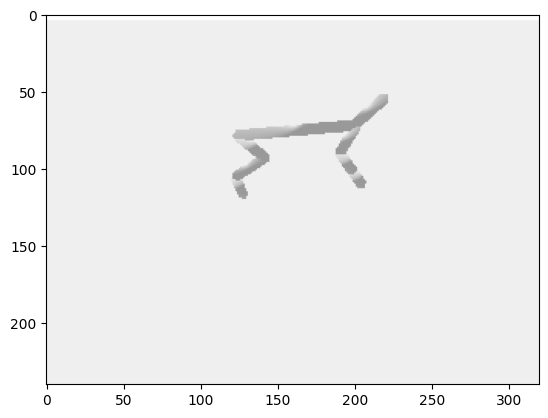

In [2]:
from mujoco_wrappers import Normalize
from logger import TensorboardSummaries as Summaries
from matplotlib import pyplot as plt

env = gym.make("HalfCheetahMuJoCoEnv-v0")
env = Normalize(Summaries(env))
env.unwrapped.seed(0)

obs = env.reset()
plt.imshow(env.render(mode="rgb_array"))

print("observation space: ", env.observation_space, "\nobservations:", env.reset())
print("action space: ", env.action_space, "\naction_sample: ", env.action_space.sample())
print("observation shape", obs.shape)

Next, you will need to define a model for training. You can use two separate networks (one for policy and another for value function) or create one with shared backbone. Recommended architecture is a 3-layer MLP with 64 hidden units, $\mathrm{tanh}$ 
activation function, weights initialized with orthogonal initializer with gain $\sqrt{2}$ and biases initialized with zeros. 

Our policy distribution is going to be multivariate normal with diagonal covariance. The policy head will predict the mean and covariance OR only mean, and the covariance then should be represented by a single (learned) vector of size 6 (corresponding to the dimensionality of the action space from above), initialized with zeros. Anyway you should guarantee that covariance is non-negative by using exponent or softplus. 

Overall the model should return three things: predicted mean of the distribution, variance vector and value estimation. 

In [3]:
from numpy import sqrt as sqrt
import torch as torch
from torch import nn
from torch.nn.functional import (
    softplus as softplus,
)


def initialize_weights(module: nn.Module, gain: float = 1.0):
    for child in module.children():
        if isinstance(child, nn.Linear):
            nn.init.orthogonal_(child.weight, gain=gain)
            if child.bias is not None:
                nn.init.zeros_(child.bias)
        elif isinstance(child, nn.Sequential):
            initialize_weights(child, gain)


class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(17, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
        )
        self.policy_mean_head = nn.Linear(64, 6)
        self.policy_variance_head = nn.Linear(64, 6)
        self.value_head = nn.Linear(64, 1)

        initialize_weights(self, gain=sqrt(2))
        nn.init.zeros_(self.policy_variance_head.weight)
        nn.init.zeros_(self.policy_variance_head.bias)

    def forward(self, state):
        internal_state_representation = self.backbone(state)
        mean = self.policy_mean_head(internal_state_representation)
        variance = softplus(self.policy_variance_head(internal_state_representation))
        value = self.value_head(internal_state_representation).squeeze(-1)
        return mean, variance, value


This model will be wrapped by a `Policy`. The policy can work in two modes, but in either case 
it is going to return dictionary with string-type keys. The first mode is when the policy is 
used to sample actions for a trajectory which will later be used for training. In this case 
the flag `training` passed to `act` method is `False` and the method should return 
a `dict` with the following keys: 

* `"actions"`: actions to pass to the environment
* `"log_probs"`: log-probabilities of sampled actions
* `"values"`: value function $V^\pi(s)$ predictions.

We don't need to use the values under these keys for training, so all of them should be of type `np.ndarray`. This regime will be used to collect data.

When `training` is `True`, the model is training on a given batch of observations. In this
case it should return a `dict` with the following keys

* `"distribution"`: an instance of multivariate normal distribution (`torch.distributions.MultivariateNormal`)
* `"values"`: value function $V^\pi(s)$ prediction, tensor

The distinction about the modes comes into play depending on where the policy is used: if it is called from `EnvRunner`, 
the `training` flag is `False`, if it is called from `PPO`, the `training` flag is `True`. These classes 
will be described below.

In [4]:
from torch.distributions import Normal, Independent
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class Policy:
    def __init__(self, model: ActorCritic):
        self.model = model

    def act(self, inputs, training=False):
        '''
        input:
            inputs - numpy array if training is False, otherwise tensor, (batch_size x features)
            training - flag, bool
        output:
            if training is True, dict containing keys ['actions', 'log_probs', 'values']:
                `distribution` - MultivariateNormal, (batch_size x actions_dim)
                'values' - critic estimations, tensor, (batch_size)
            if training is False, dict containing keys ['actions', 'log_probs', 'values']:
                'actions' - selected actions, numpy, (batch_size)
                'log_probs' - log probs of selected actions, numpy, (batch_size)
                'values' - critic estimations, numpy, (batch_size)
        '''
        # if training is false, input is numpy
        if not training:
            inputs = torch.tensor(inputs, dtype=torch.float32, device=DEVICE)     
        
        mean, variance, value = self.model(inputs)

        distribution = Independent(Normal(mean, variance.sqrt()), 1)
        if training:
            return {
                "distribution": distribution,
                "values": value
            }
        else:
            actions = distribution.sample()
            log_probs = distribution.log_prob(actions)
            values = value
            return {
                "actions": actions.numpy(force=True),
                "log_probs": log_probs.numpy(force=True),
                "values": values.numpy(force=True)
            }

We will use `EnvRunner` to perform interactions with an environment with a policy for a fixed number of timesteps. Calling `.get_next()` on a runner will return a trajectory &mdash; dictionary 
containing keys

* `"observations"`
* `"rewards"` 
* `"dones"`
* `"actions"`
* all other keys that you defined in `Policy` in `training=False` regime,

under each of these keys there is a `np.ndarray` of specified length $T$ &mdash; the size of partial trajectory. 

In [5]:
from runners import EnvRunner

Additionally, before returning a trajectory this runner can apply a list of transformations. 
Each transformation is simply a callable that should modify passed trajectory in-place.

In [6]:
import numpy as np

class AsArray:
    """ 
    Converts lists of interactions to ndarray.
    """
    def __call__(self, trajectory, last_observation):
        # Modifies trajectory inplace.
        # Just switches python lists to numpy arrays
        for k, v in trajectory.items():
            trajectory[k] = np.asarray(v)

Let's have a look at how this works.

In [7]:
model = ActorCritic().to(DEVICE)
policy = Policy(model)
runner = EnvRunner(env, policy, nsteps=5, transforms=[AsArray()])

In [8]:
# generates new rollout
trajectory = runner.get_next()

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


In [9]:
# what is inside
print(trajectory.keys())

dict_keys(['actions', 'log_probs', 'values', 'observations', 'rewards', 'dones'])


In [10]:
# Sanity checks
assert 'log_probs' in trajectory, "Not found: policy didn't provide log_probs of selected actions"
assert 'values' in trajectory, "Not found: policy didn't provide critic estimations"
assert trajectory['log_probs'].shape == (5,), "log_probs wrong shape"
assert trajectory['values'].shape == (5,), "values wrong shape"
assert trajectory['observations'].shape == (5, 17), "observations wrong shape"
assert trajectory['rewards'].shape == (5,), "rewards wrong shape"
assert trajectory['dones'].shape == (5,), "dones wrong shape"

In [11]:
# Here is what collected inside
{k: v.shape for k, v in trajectory.items()}

{'actions': (5, 6),
 'log_probs': (5,),
 'values': (5,),
 'observations': (5, 17),
 'rewards': (5,),
 'dones': (5,)}

You will need to implement the following two transformations. 

The first is `GAE` that implements [Generalized Advantage Estimator](https://arxiv.org/abs/1506.02438).
In it you should add two keys to the trajectory: `"advantages"` and `"value_targets"`. In GAE the advantages
$A_t^{\mathrm{GAE}(\gamma,\lambda)}$ are essentially defined as the exponential 
moving average with parameter $\lambda$ of the regular advantages 
$\hat{A}^{(T)}(s_t) = \sum_{l=0}^{T-1-t} \gamma^l r_{t+l} + \gamma^{T} V^\pi(s_{T}) - V^\pi(s_t)$. 
The exact formula for the computation is the following

$$
A_{t}^{\mathrm{GAE}(\gamma,\lambda)} = \sum_{l=0}^{T-1-t} (\gamma\lambda)^l\delta_{t + l}^V, \, t \in [0, T)
$$
where $\delta_{t+l}^V = r_{t+l} + \gamma V^\pi(s_{t+l+1}) - V^\pi(s_{t+l})$. You can look at the 
derivation (formulas 11-16) in the paper. Don't forget to reset the summation on terminal
states as determined by the flags `trajectory["dones"]`. You can use `trajectory["values"]`
to get values of all observations except the most recent which is stored under 
 `trajectory["state"]["latest_observation"]`. For this observation you will need to call the policy 
 to get the value prediction.

Once you computed the advantages, you can get the targets for training the value function by adding 
back values:
$$
\hat{V}(s_{t+l}) = A_{t+l}^{\mathrm{GAE}(\gamma,\lambda)} + V(s_{t + l}),
$$
where $\hat{V}$ is a tensor of value targets that are used to train the value function. 

In [12]:
class GAE:
    """Generalized Advantage Estimator."""

    def __init__(self, policy: Policy, gamma=0.99, gae_lambda=0.95):
        self.policy = policy
        self.gamma = gamma
        self.gae_lambda = gae_lambda

    def __call__(self, trajectory: dict[str, np.ndarray], last_observation: np.ndarray):
        """
        This method should modify trajectory inplace by adding
        items with keys 'advantages' and 'value_targets' to it

        input:
            trajectory - dict from runner
            latest_observation - last state, numpy, (features)
        """
        last_outputs = self.policy.act(last_observation)
        last_value = last_outputs["values"]
        values = trajectory["values"]
        rewards = trajectory["rewards"]
        terms = trajectory["dones"]
        advantages = []
        last_gae_lambda = np.zeros_like(values[-1])
        for t in reversed(range(len(rewards))):
            nonterms_t = 1 - terms[t]
            delta = rewards[t] + self.gamma * nonterms_t * last_value - values[t]
            last_gae_lambda = delta + self.gamma * self.gae_lambda * nonterms_t * last_gae_lambda
            last_value = values[t]
            advantages.append(last_gae_lambda)
        advantages.reverse()
        value_targets = list(map(lambda x, y: x + y, values, advantages))

        trajectory["advantages"] = np.array(advantages)
        trajectory["value_targets"] = np.array(value_targets)

Let's run a small test just in case.

In [13]:
# tests
class DummyEnv():
    def __init__(self):
        self.unwrapped = None
        self.t = 0
        self.state = np.zeros(17)
    
    def reset(self):
        return self.state
    
    def step(self, a):
        r = [0, -100, 800][self.t]
        done = self.t == 2
        self.t = (self.t + 1) % 3
        return self.state, r, done, {}
    
class DummyPolicy():
    def act(self, s):
        return {"values": np.array(100), "actions": np.array([-0.42, 0.42])}

dummy_env = DummyEnv()
dummy_policy = DummyPolicy()
runner = EnvRunner(dummy_env, dummy_policy, nsteps=8, transforms=[AsArray(), GAE(dummy_policy, gamma=0.8, gae_lambda=0.5)])
trajectory = runner.get_next()

In [14]:
assert 'advantages' in trajectory, "Not found: advantage estimation"
assert 'value_targets' in trajectory, "Not found: targets for critic"
assert trajectory['advantages'].shape == (8,), "advantage wrong shape"
assert trajectory['value_targets'].shape == (8,), "value_targets wrong shape"
assert (trajectory['advantages'] == np.array([44, 160, 700, 44, 160, 700, -68, -120])).all(), "advantage computation error"
assert (trajectory['value_targets'] == trajectory['advantages'] + 100).all(), "value targets computation error"
print("Nice!")

Nice!


The main advantage of PPO over simpler policy based methods like A2C is that it is possible
to train on the same trajectory for multiple gradient steps. The following class wraps 
an `EnvRunner`. It should call the runner to get a trajectory, then return minibatches 
from it for a number of epochs, shuffling the data before each epoch. The number of minibatches per epoch is predefined in `num_minibatches`.

In [15]:
class Sampler:
    """Samples minibatches from trajectory for a number of epochs."""

    def __init__(self, runner, num_epochs, num_minibatches, transforms=None):
        self.runner = runner
        self.num_epochs = num_epochs
        self.num_minibatches = num_minibatches
        self.transforms = transforms or []

    def get_next(self):
        """
        Yields next minibatch (dict) for training with at least following keys:
                'observations' - numpy, (batch_size x features)
                'actions' - numpy, (batch_size x actions_dim)
                'advantages' - numpy, (batch_size)
                'log_probs' - numpy, (batch_size)
        """
        trajectory = self.runner.get_next()
        
        # Calculate the actual size of each minibatch
        batch_size = len(trajectory["observations"]) // self.num_minibatches

        for epoch in range(self.num_epochs):
            # shuffle dataset and separate it into minibatches
            ids = np.random.permutation(len(trajectory["observations"]))
            
            # Step by batch_size, not by num_minibatches
            for i in range(0, len(ids), batch_size):
                minibatch = {k: v[ids[i : i + batch_size]] for k, v in trajectory.items()}

                for transform in self.transforms:
                    transform(minibatch)

                yield minibatch

A common trick to use with GAE is to normalize advantages for every minibatch, the following transformation does that. 

In [16]:
class NormalizeAdvantages:
    """ Normalizes advantages to have zero mean and variance 1. """
    def __call__(self, batch):
        adv = batch["advantages"]
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        batch["advantages"] = adv

In [17]:
class PyTorchify:
    """ Moves everything to PyTorch """
    def __call__(self, batch):
        for k, v in batch.items():
            batch[k] = torch.tensor(v, dtype=torch.float32, device=DEVICE)

Finally, we can create our PPO runner! This is our pipeline of data collecting and generating mini-batches for our trainer!

In [18]:
def make_ppo_sampler(env, policy, num_runner_steps=2048, gamma=0.99, gae_lambda=0.95, num_epochs=10, num_minibatches=32):
    """Creates runner for PPO algorithm."""
    runner_transforms = [AsArray(), GAE(policy, gamma=gamma, gae_lambda=gae_lambda)]
    runner = EnvRunner(env, policy, num_runner_steps, transforms=runner_transforms)

    sampler_transforms = [NormalizeAdvantages(), PyTorchify()]
    sampler = Sampler(runner, num_epochs=num_epochs, num_minibatches=num_minibatches, transforms=sampler_transforms)
    return sampler

In the next cell you will need to implement Proximal Policy Optimization algorithm itself. The algorithm
modifies the typical policy gradient loss in the following way:

$$
J_{\pi}(s, a) = \frac{\pi_\theta(a|s)}{\pi_\theta^{\text{old}}(a|s)} \cdot A^{\mathrm{GAE}(\gamma,\lambda)}(s, a)
$$

$$
J_{\pi}^{\text{clipped}}(s, a) = \mathrm{clip}\left(
\frac{\pi_\theta(a|s)}{\pi_{\theta^{\text{old}}}(a|s)},
1 - \text{cliprange}, 1 + \text{cliprange}\right)\cdot A^{\mathrm{GAE(\gamma, \lambda)}}(s)\\
$$

$$
L_{\text{policy}} = -\frac{1}{T}\sum_{l=0}^{T-1}\min\left(J_\pi(s_{t + l}, a_{t + l}), J_{\pi}^{\text{clipped}}(s_{t + l}, a_{t + l})\right).
$$

The value loss is also modified:

$$
L_{V}^{\text{clipped}} = \frac{1}{T}\sum_{l=0}^{T-1} \max(l^{simple}(s_{t + l}), l^{clipped}(s_{t + l})),
$$
where $l^{simple}$ is your standard critic loss
$$
l^{simple}(s_{t + l}) = [V_\theta(s_{t+l}) - \hat{V}(s_{t + l})]^2
$$

and $l^{clipped}$ is a clipped version that limits large changes of the value function:
$$
l^{clipped}(s_{t + l}) = [
V_{\theta^{\text{old}}}(s_{t+l}) +
\text{clip}\left(
V_\theta(s_{t+l}) - V_{\theta^\text{old}}(s_{t+l}),
-\text{cliprange}, \text{cliprange}
\right) - \hat{V}(s_{t + l})] ^ 2
$$

In [19]:
from torch.nn.utils import clip_grad_norm_


class PPO:
    def __init__(self, policy, optimizer, sampler, pg_cliprange=0.2, vf_cliprange=0.2, value_loss_coef=0.25, ent_loss_coef=0.01, max_grad_norm=0.5):
        self.policy = policy
        self.optimizer = optimizer
        self.sampler = sampler
        self.pg_cliprange = pg_cliprange
        self.vf_cliprange = vf_cliprange
        self.value_loss_coef = value_loss_coef
        self.ent_loss_coef = ent_loss_coef
        self.max_grad_norm = max_grad_norm
        self.iteration = 0

    def write(self, name, val):
        """For logging purposes"""
        self.sampler.runner.write(name, val, self.iteration)

    def policy_loss(self, batch, act):
        """
        Computes and returns policy loss on a given minibatch.
        input:
            batch - dict from sampler, containing:
                'advantages' - advantage estimation, tensor, (batch_size)
                'actions' - actions selected in real trajectory, (batch_size)
                'log_probs' - probabilities of actions from policy used to collect this trajectory, (batch_size)
            act - dict from your current policy, containing:
                'distribution' - MultivariateNormal, (batch_size x actions_dim)
        output:
            policy loss - torch scalar
        """
        adv = batch["advantages"]
        old_log_probs = batch["log_probs"]
        acts = batch["actions"]
        dist = act["distribution"]

        new_log_probs = dist.log_prob(acts)
        ratio = torch.exp(new_log_probs - old_log_probs)
        clipped_ratio = torch.clamp(ratio, 1 - self.pg_cliprange, 1 + self.pg_cliprange)

        policy_loss = -torch.mean(torch.min(ratio * adv, clipped_ratio * adv))

        entropy = dist.entropy().mean()
        clipfrac = torch.mean((torch.abs(ratio - 1.0) > self.pg_cliprange).float())
        max_ratio = torch.max(ratio)

        self.write("policy/loss", policy_loss.item())
        self.write("policy/entropy", entropy.item())
        self.write("policy/clipfrac", clipfrac.item())
        self.write("policy/max_ratio", max_ratio.item())

        return policy_loss, entropy

    def value_loss(self, batch, act):
        """
        Computes and returns value loss on a given minibatch.
        """
        assert batch["value_targets"].shape == act["values"].shape, "Danger: your values and value targets have different shape. Watch your broadcasting!"
        value_targets = batch["value_targets"]
        old_values = batch["values"]
        values = act["values"]

        simple_loss = (values - value_targets).pow(2)
        clipped_loss = (old_values + torch.clamp(values - old_values, -self.vf_cliprange, self.vf_cliprange) - value_targets).pow(2)

        vf_loss = torch.mean(torch.max(simple_loss, clipped_loss))

        clipfrac = torch.mean((torch.abs(values - old_values) > self.vf_cliprange).float())

        self.write("vf/loss", vf_loss.item())
        self.write("vf/predictions", values.mean().item())
        self.write("vf/clipfrac", clipfrac.item())

        return vf_loss

    def loss(self, batch):
        """Computes loss for current batch"""

        # let's run our current policy on this batch
        # let's run our current policy on this batch
        act = self.policy.act(batch["observations"], training=True)

        # compute losses
        pg_loss, ent = self.policy_loss(batch, act)
        vf_loss = self.value_loss(batch, act)

        total_loss = pg_loss + self.value_loss_coef * vf_loss - self.ent_loss_coef * ent

        # Return scalar loss
        return total_loss

    def step(self, batch):
        """Computes the loss function and performs a single gradient step for this batch."""
        self.optimizer.zero_grad()
        loss = self.loss(batch)
        loss.backward()

        # do not forget to clip gradients using self.max_grad_norm
        # and log gradient norm
        grad_norm = clip_grad_norm_(self.policy.model.parameters(), self.max_grad_norm)
        self.optimizer.step()

        self.write("grad_norm", grad_norm.item())

        # this is for logging
        self.iteration += 1

Now everything is ready to do training. In **one million of interactions** it should be possible to 
achieve the average raw reward over last 100 episodes more than 1500. **Your goal is to reach 1000**.

For optimization it is suggested to use Adam optimizer with learning rate 3e-4 and epsilon 1e-5.

**Notes**:
* reward should rise quickly in this environment. If it is stuck, something went wrong.
* you can linearly decay learning rate if you face instabilities.
* we wrote additional logs with respect to *number of network updates* since we perform many updates after each data collection stage.

In [20]:
model = ActorCritic().to(DEVICE)
policy = Policy(model)
total_interactions = 1_000_000
interactions_per_rollout = 2048
num_updates = total_interactions // interactions_per_rollout
sampler = make_ppo_sampler(env, policy)

optimizer = torch.optim.Adam(policy.model.parameters(), lr=3e-4, eps=1e-5)
ppo = PPO(policy, optimizer, sampler)

In [21]:
from tqdm import tqdm


# Progress bar for the outer loop
for update in tqdm(range(num_updates), desc="Training"):
    for minibatch in sampler.get_next():
        ppo.step(minibatch)

print("Training finished!")

Training: 100%|██████████| 488/488 [24:25<00:00,  3.00s/it]

Training finished!


![metrics](metrics.png)

**Note:** remember that we learned not only the weights of policy model, but also statistics for input normalization, so to save our results we need to store them too.

In [22]:
# save your model just in case

def save(model, env, name):
    torch.save(model.state_dict(), name)
    np.save(name + "_mean_ob", env.obs_rmv.mean)
    np.save(name + "_var_ob", env.obs_rmv.var)
    np.save(name + "_count_ob", env.obs_rmv.count)
    
save(model, env, "PPO")

In [23]:
# loading the model

def load(model, env, name):
    model.load_state_dict(torch.load(name))
    env.obs_rmv.mean = np.load(name + "_mean_ob.npy")
    env.obs_rmv.var = np.load(name + "_var_ob.npy")
    env.obs_rmv.count = np.load(name + "_count_ob.npy")
    
load(model, env, "PPO")

/tmp/ipykernel_73540/3793190188.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(name))


## Evaluation

In [24]:
def evaluate(env, policy, n_games=1, t_max=1000):
    '''
    Plays n_games and returns rewards and rendered games
    '''
    rewards = []
    
    for _ in range(n_games):
        s = env.reset()
        
        R = 0
        for _ in range(t_max):
            action = policy.act(np.array([s]))["actions"][0]
            
            s, _, done, info = env.step(action)
            
            # remember that we used a wrapper that normalizes reward
            # original reward per step comes here
            R += info["original reward"]
                
            if done:
                break

        rewards.append(R)
    return np.array(rewards)

In [25]:
# evaluation will take some time!
sessions = evaluate(env, policy, n_games=20)
score = sessions.mean()
print(f"Your score: {score}")

assert score >= 1000, "Needs more training?"
print("Well done!")

Your score: 1708.7365546705623
Well done!


## Record

In [30]:
# let's hope this will work
# don't forget to pray
env = gym.wrappers.RecordVideo(env, video_folder="videos")

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /root/workspace/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [31]:
# record sessions
# note that t_max is 300, so collected reward will be smaller than 1000
evaluate(env, policy, n_games=1, t_max=300)

/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:67: DeprecationWarning: WARN: `env.metadata["render.modes"] is marked as deprecated and will be replaced with `env.metadata["render_modes"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment HalfCheetahMuJoCoEnv-v0 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:149: DeprecationWarning: WARN: `env.metadata["video.frames_per_second"] is marked as deprecated and will be replaced with `env.metadata["render_fps"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.11/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argum

array([463.83922565])

In [32]:
env.close()

<video src="videos/rl-video-episode-0.mp4" controls width="600"></video>
